# 📊 E-Commerce Sales Analysis

## 📌 Business Context
Perusahaan e-commerce ingin memahami performa penjualan untuk meningkatkan revenue dan menentukan strategi bisnis yang lebih efektif.

---

## 🎯 Objectives
- Menganalisis tren revenue bulanan  
- Mengidentifikasi kategori dan produk terbaik  
- Menganalisis performa wilayah  
- Menganalisis metode pembayaran pelanggan  
- Memberikan rekomendasi berbasis data  

---

## 📌 Workflow
1. Data Understanding  
2. Data Preparation  
3. Exploratory Data Analysis (EDA)  
4. Conclusion  

In [40]:
# Import library utama untuk data analysis dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling visualisasi agar lebih clean
sns.set(style='whitegrid')

In [41]:
# Load dataset
df = pd.read_csv('../data/raw_data.csv')

# Menampilkan 5 data pertama
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


# 📊 Data Understanding

Tahap ini bertujuan untuk memahami struktur dataset, tipe data, dan kondisi awal data.

In [42]:
# Melihat informasi dataset (tipe data, jumlah data)
df.info()

# Statistik deskriptif
df.describe()

# Mengecek missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

### 💡 Insight
- Dataset berisi data transaksi seperti produk, kategori, revenue, region, dan metode pembayaran  
- Struktur data sudah lengkap dan siap digunakan  
- Tidak ditemukan missing value signifikan  

# 🧹 Data Preparation

Tahap ini bertujuan untuk membersihkan data dan menyiapkannya sebelum analisis.

In [43]:
# =========================
# DATA PREPARATION
# =========================

# 1. Rapihin nama kolom (anti error)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Cek ulang kolom
print(df.columns)

# 2. Convert kolom date ke datetime
df['date'] = pd.to_datetime(df['date'])

# 3. Buat kolom month
df['month'] = df['date'].dt.month

# Cek hasil
df[['date','month']].head()

Index(['transaction_id', 'date', 'product_category', 'product_name',
       'units_sold', 'unit_price', 'total_revenue', 'region',
       'payment_method'],
      dtype='object')


,date,month
0,2024-01-01,1
1,2024-01-02,1
2,2024-01-03,1
3,2024-01-04,1
4,2024-01-05,1


### 💡 Insight
- Nama kolom sudah distandarisasi untuk menghindari error  
- Kolom Month berhasil dibuat untuk analisis tren waktu  
- Dataset siap digunakan untuk EDA  

# 📊 Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk menemukan pola dan insight dari data.

In [44]:
# =========================
# TOTAL REVENUE
# =========================

# Menghitung total revenue keseluruhan
total_revenue = df['total_revenue'].sum()

print(f"Total Revenue: {total_revenue:,.0f}")

Total Revenue: 80,568


### 💡 Insight
- Total revenue menunjukkan performa keseluruhan bisnis  
- KPI ini penting sebagai baseline untuk analisis selanjutnya  

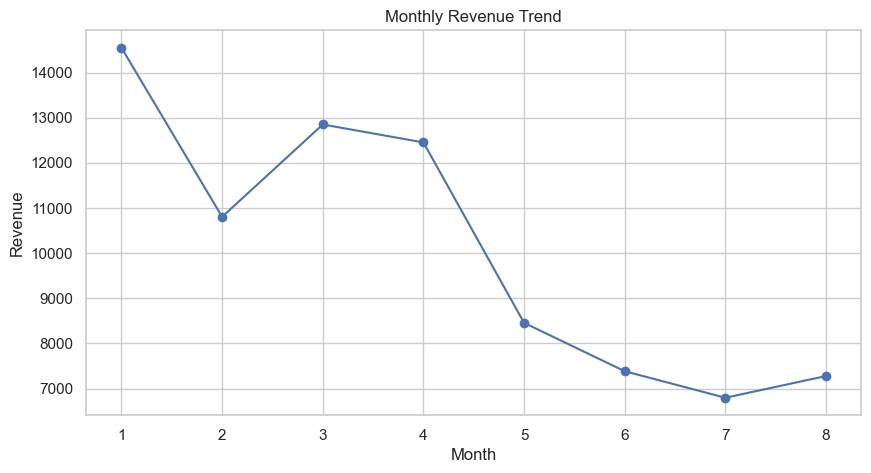

In [45]:
# =========================
# MONTHLY REVENUE
# =========================

# Gunakan total_revenue (bukan revenue)
monthly_revenue = df.groupby('month')['total_revenue'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### 💡 Insight
- Revenue mengalami tren menurun dari Januari hingga Juli  
- Terdapat sedikit peningkatan pada bulan Agustus  

👉 **Interpretasi:**
- Penurunan ini bisa disebabkan oleh seasonality atau penurunan demand  

👉 **Rekomendasi:**
- Lakukan promosi pada periode penurunan  

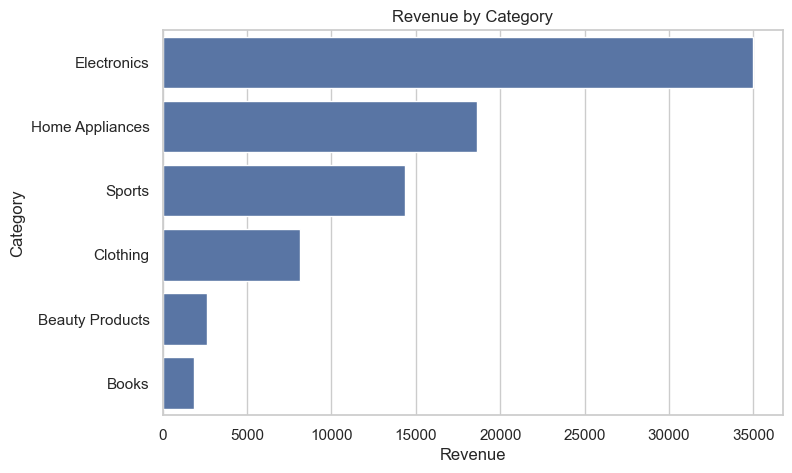

In [46]:
# =========================
# REVENUE BY CATEGORY
# =========================

# Menghitung revenue per kategori produk
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

# Visualisasi
plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.values, y=category_revenue.index)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

### 💡 Insight
- Electronics menjadi kategori dengan kontribusi revenue terbesar  
- Kategori lain memiliki kontribusi lebih kecil  

👉 **Rekomendasi:**
- Fokus pada kategori dengan performa tinggi  

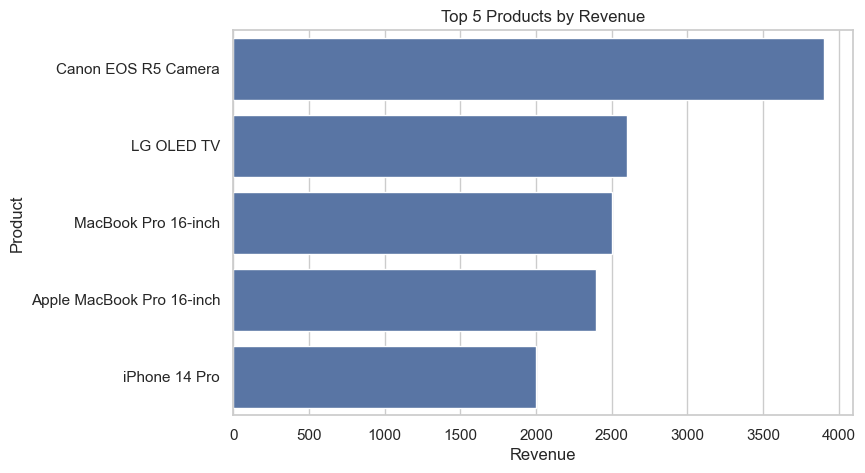

In [47]:
# =========================
# TOP PRODUCTS
# =========================

# Mengambil 5 produk dengan revenue tertinggi
top_product = df.groupby('product_name')['total_revenue'].sum().sort_values(ascending=False).head(5)

# Visualisasi
plt.figure(figsize=(8,5))
sns.barplot(x=top_product.values, y=top_product.index)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

### 💡 Insight
- Produk premium mendominasi revenue  
- Produk seperti Canon EOS R5 Camera memiliki performa terbaik  

👉 **Rekomendasi:**
- Fokus pada strategi upselling produk premium  

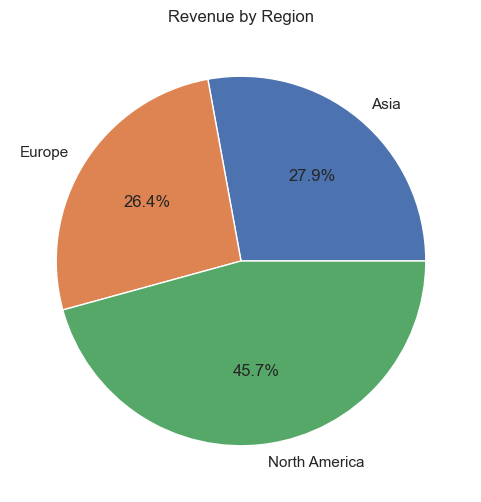

In [48]:
# =========================
# REVENUE BY REGION
# =========================

# Menghitung revenue berdasarkan region
region_revenue = df.groupby('region')['total_revenue'].sum()

# Visualisasi pie chart
plt.figure(figsize=(6,6))
plt.pie(region_revenue, labels=region_revenue.index, autopct='%1.1f%%')

plt.title("Revenue by Region")
plt.show()

### 💡 Insight
- North America menjadi region dengan kontribusi terbesar  
- Region lain masih memiliki potensi pertumbuhan  

👉 **Rekomendasi:**
- Perlu ekspansi ke region dengan kontribusi rendah  

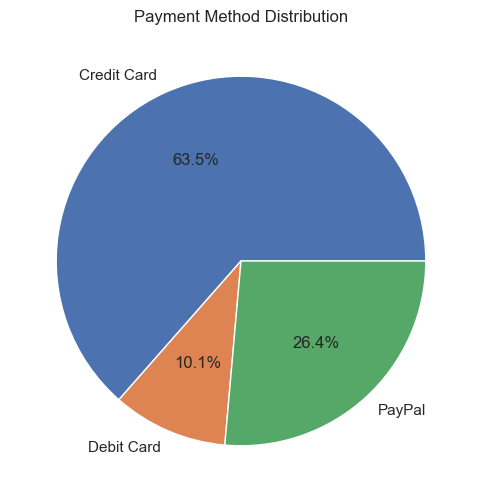

In [49]:
# =========================
# PAYMENT METHOD
# =========================

# Menghitung revenue berdasarkan metode pembayaran
payment = df.groupby('payment_method')['total_revenue'].sum()

# Visualisasi pie chart
plt.figure(figsize=(6,6))
plt.pie(payment, labels=payment.index, autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

### 💡 Insight
- Credit Card merupakan metode pembayaran paling dominan  

👉 **Rekomendasi:**
- Optimalkan metode pembayaran populer untuk meningkatkan konversi  

# 💡 Key Insights

- Revenue menunjukkan tren menurun dari Januari hingga Juli, dengan sedikit peningkatan di Agustus  
- Kategori Electronics menjadi penyumbang revenue terbesar dibanding kategori lain  
- Produk premium seperti Canon EOS R5 Camera mendominasi penjualan  
- North America merupakan region dengan kontribusi revenue tertinggi  
- Credit Card menjadi metode pembayaran paling dominan (~63%)  

# 📌 Business Conclusion

Berdasarkan analisis data penjualan e-commerce:

- Performa penjualan mengalami penurunan di pertengahan tahun, yang menunjukkan adanya potensi masalah pada demand atau strategi marketing  
- Produk dan kategori high-value menjadi kontributor utama revenue  
- Distribusi penjualan masih terpusat di region tertentu  
- Preferensi pembayaran pelanggan cenderung pada metode Credit Card  

👉 Secara keseluruhan, bisnis memiliki potensi besar namun perlu optimasi strategi untuk meningkatkan performa di periode tertentu

# 🚀 Business Recommendations

1. **Optimasi Marketing di Periode Low Sales**
   - Lakukan promo atau campaign di bulan dengan penurunan revenue  

2. **Fokus pada Produk & Kategori High-Value**
   - Tingkatkan promosi pada kategori Electronics dan produk premium  

3. **Ekspansi ke Region Potensial**
   - Kembangkan strategi marketing di region selain North America  

4. **Optimalkan Metode Pembayaran**
   - Maksimalkan penggunaan Credit Card dan berikan insentif untuk metode lain  

5. **Strategi Upselling**
   - Tawarkan produk premium kepada pelanggan untuk meningkatkan revenue  

In [50]:
# =========================
# SAVE CLEAN DATA
# =========================

df.to_csv('../data/clean_data.csv', index=False)

In [51]:
# =========================
# SUMMARY DATA
# =========================

summary = df.groupby('product_category')['total_revenue'].sum().reset_index()

# save
summary.to_csv('../output/summary.csv', index=False)